# Mini-CLIP – ein exploratives Logbuch

**Paper:** *Learning Transferable Visual Models From Natural Language Supervision* (CLIP, Radford et al., 2021, arXiv:2103.00020)

In diesem Notebook dokumentieren wir, wie unser Mini-CLIP entstanden ist – nicht nur das fertige Ergebnis, sondern auch die Umwege. Wir fanden das ehrlicher als eine geglättete Doku, und man versteht die Entscheidungen besser, wenn man sieht, woran wir zwischendurch gescheitert sind.

Der rote Faden:
1. Wie vergleicht man überhaupt ein Bild mit einem Text?
2. Der kontrastive Loss – und warum unsere erste, naive Variante kollabiert.
3. Die Encoder (klein gehalten, wir haben nur eine CPU).
4. Sanity-Check auf synthetischen Daten – und eine Metrik, die uns in die Irre geführt hat.
5. Parameter unter der Lupe: Temperatur & L2-Normalisierung.
6. Echte Daten (Flickr8k) – die Mühen der Datenbeschaffung.
7. Training und die Overfitting-Entdeckung.
8. Experiment zur Batchgröße – mit einem Ergebnis, das wir so nicht erwartet hatten.
9. Baseline gegen vortrainiertes CLIP – drei Anläufe, bis es lief.

> Hinweis: Leichte Experimente laufen live (CPU, Sekunden). Die teuren Läufe (volles Flickr8k-Training, Download von CLIP) sind über das Flag `RUN_HEAVY` abgeschaltet; stattdessen zeigen wir die *tatsächlich protokollierten* Ergebnisse und die erzeugten Abbildungen. Wer alles selbst nachrechnen will: Abschnitt 12.

In [1]:
import sys, os, math, random, time
import numpy as np
import torch
import matplotlib.pyplot as plt

# Reproduzierbarkeit
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(4)

RUN_HEAVY = False   # auf True setzen, um volles Flickr8k-Training/Download selbst zu fahren
print("PyTorch", torch.__version__, "| Device: CPU (bewusst – Studienprojekt ohne GPU)")

PyTorch 2.12.1 | Device: CPU (bewusst – Studienprojekt ohne GPU)


## 1 · Wie vergleicht man ein Bild mit einem Text?

Die Grundidee von CLIP ist, dass ein Bild-Encoder und ein Text-Encoder ihre Eingabe jeweils in einen Vektor derselben Dimension abbilden, den gemeinsamen Embedding-Raum. Zusammengehörige (Bild, Text)-Paare sollen dort nah beieinander liegen.

Bleibt die Frage, wie man "nah beieinander" misst. Naheliegend ist das Skalarprodukt. Dabei ist uns aber schnell aufgefallen: Wenn die Vektoren unterschiedlich lang sind, dominiert die Länge die Ähnlichkeit und nicht die Richtung. Das Paper löst das, indem es die Vektoren L2-normalisiert – dann ist das Skalarprodukt die Kosinus-Ähnlichkeit und liegt sauber in `[-1, 1]`. Wir machen es genauso, im Modell weiter unten sieht man die Stelle.

## 2 · Der kontrastive Loss – und eine Sackgasse

**Sackgasse #1:** Unser erster Gedanke war, dass es doch reichen müsste, die Ähnlichkeit der echten Paare zu maximieren. Warum die falschen Paare überhaupt anfassen? Das haben wir ausprobiert, und es funktioniert nicht. Eine solche *Positive-only*-Variante erzeugt keinerlei Druck, Nicht-Paare voneinander zu trennen. Die Diagonale wird zwar hoch, aber die Off-Diagonale bleibt einfach da, wo die Initialisierung sie hingelegt hat. Ein frisch initialisierter Encoder liefert fast konstante Ausgaben – dann bleiben alle Paare ununterscheidbar nah beieinander, und der Margin (der Abstand zwischen Diagonale und Off-Diagonale) bleibt winzig.

Um das zu zeigen, bauen wir uns ein Minimalbeispiel mit 16 Konzepten, deren Bild- und Text-Vektoren absichtlich nahezu kollabiert starten, so wie bei einem untrainierten Encoder. Einmal optimieren wir nur die positiven Paare (naiv), einmal den symmetrischen InfoNCE-Loss aus dem Paper. Worauf wir achten, ist der Margin.

In [2]:
def normalize(x):
    return x / x.norm(dim=-1, keepdim=True)

def stats(img, txt):
    sim = normalize(img.detach()) @ normalize(txt.detach()).t()
    n = len(sim); off = ~torch.eye(n, dtype=bool)
    return sim.diag().mean().item(), sim[off].mean().item()

def init_near_collapsed():
    # alle Vektoren starten nahe derselben Richtung -> simuliert untrainierten Encoder
    torch.manual_seed(0); N, d = 16, 8
    base = torch.zeros(d); base[0] = 1.0
    img = (base + 0.15*torch.randn(N, d)).clone().requires_grad_(True)
    txt = (base + 0.15*torch.randn(N, d)).clone().requires_grad_(True)
    return N, img, txt

d0, o0 = stats(*init_near_collapsed()[1:])
print(f"START (fast kollabiert): Diagonale={d0:.2f}  Off-Diagonale={o0:.2f}  Margin={d0-o0:.2f}")

# --- naiv: nur positive Paare anziehen ---
N, img, txt = init_near_collapsed()
opt = torch.optim.Adam([img, txt], lr=0.05)
for _ in range(400):
    loss = -(normalize(img) * normalize(txt)).sum(1).mean()   # nur Diagonale hoch
    opt.zero_grad(); loss.backward(); opt.step()
d, o = stats(img, txt)
print(f"NAIV   : Diagonale={d:.2f}  Off-Diagonale={o:.2f}  Margin={d-o:.2f}")
print("         -> Off-Diagonale bleibt hoch: Nicht-Paare werden NICHT getrennt.")

START (fast kollabiert): Diagonale=0.88  Off-Diagonale=0.87  Margin=0.01


NAIV   : Diagonale=1.00  Off-Diagonale=0.89  Margin=0.11
         -> Off-Diagonale bleibt hoch: Nicht-Paare werden NICHT getrennt.


In [3]:
# --- korrekt: symmetrischer InfoNCE mit In-Batch-Negativen ---
def info_nce(img, txt, scale=10.0):
    logits = scale * normalize(img) @ normalize(txt).t()
    tgt = torch.arange(len(img))
    return 0.5 * (torch.nn.functional.cross_entropy(logits, tgt) +
                  torch.nn.functional.cross_entropy(logits.t(), tgt))

N, img, txt = init_near_collapsed()
opt = torch.optim.Adam([img, txt], lr=0.05)
for _ in range(400):
    loss = info_nce(img, txt)
    opt.zero_grad(); loss.backward(); opt.step()
d, o = stats(img, txt)
print(f"InfoNCE: Diagonale={d:.2f}  Off-Diagonale={o:.2f}  Margin={d-o:.2f}")
print("         -> Negative werden aktiv weggedrückt (Off-Diagonale < 0): großer Margin, robuste Trennung.")

InfoNCE: Diagonale=1.00  Off-Diagonale=-0.06  Margin=1.06
         -> Negative werden aktiv weggedrückt (Off-Diagonale < 0): großer Margin, robuste Trennung.


Beide Varianten bekommen die Diagonale hoch, aber nur InfoNCE drückt auch die Off-Diagonale herunter und schafft damit einen großen Margin. Die naive Variante übt keinen Trenndruck aus, die Unterscheidbarkeit bleibt dem Zufall der Initialisierung überlassen. Deshalb ist CLIPs Loss kontrastiv, und deshalb ist er symmetrisch (Bild→Text und Text→Bild). Den `scale`-Faktor, der oben schon auftaucht, schauen wir uns in Abschnitt 5 genauer an.

## 3 · Die Encoder – bewusst klein

Das Original nutzt ein ResNet oder ViT (zig Millionen Parameter) und einen 63M-Parameter-Text-Transformer mit BPE-Tokenizer (49k Vokabular). Auf einer CPU ist das illusorisch – ein einziger Forward-Pass durch ein ResNet-50 bei 224 px dauert länger als bei uns eine ganze Trainingsepoche. Wir haben deshalb alles radikal verkleinert, aber die Struktur beibehalten: kleines CNN, 2-Layer-Text-Transformer, Wort-Tokenizer, 256-dimensionaler gemeinsamer Raum. Der komplette Code folgt direkt hier im Notebook.

Den Code zeigen wir vollständig hier im Notebook (identisch zu `src/` im Repo, das auch die Trainingsskripte nutzen). Nur zwei Bausteine bleiben Importe, weil sie reine Fleißarbeit sind und hier nichts erklären würden: der Wort-Tokenizer (`src/tokenizer.py`) und später der Flickr-Cache-Loader (`CachedFlickr`).

Zuerst die Konfiguration. Wir haben alle Hyperparameter an eine Stelle gelegt, damit wir bei Experimenten nicht in fünf Dateien suchen müssen und jede Zahl in der Ausarbeitung nachvollziehbar bleibt:

In [4]:
from dataclasses import dataclass, field


@dataclass
class Config:
    # --- Daten ---
    image_size: int = 64            # Kantenlaenge (quadratisch). Klein halten fuer CPU.
    max_text_len: int = 32          # max. Tokens pro Caption (inkl. <bos>/<eos>)
    min_word_freq: int = 1          # Mindesthaeufigkeit, damit ein Wort ins Vokabular kommt

    # --- Modell (bewusst klein -> CPU-tauglich) ---
    embed_dim: int = 256            # gemeinsame Embedding-Dimension (shared space)
    # Text-Encoder
    text_width: int = 128           # d_model des Text-Transformers
    text_heads: int = 4
    text_layers: int = 2
    # Bild-Encoder
    vision_channels: tuple = (32, 64, 128, 256)  # Kanaele je Conv-Block

    # --- Kontrastiver Loss ---
    init_logit_scale: float = 0.07  # Start-Temperatur (wie im CLIP-Paper)
    max_logit_scale: float = 100.0  # logit_scale wird auf <= 100 geclippt

    # --- Training ---
    batch_size: int = 128
    epochs: int = 15
    lr: float = 5e-4
    weight_decay: float = 0.2
    warmup_steps: int = 50
    seed: int = 42
    num_workers: int = 0            # 0 = sicher auf CPU/macOS

    # --- Pfade ---
    data_root: str = "data"
    ckpt_path: str = "checkpoints/mini_clip.pt"
    device: str = "cpu"


Der Bild-Encoder: vier Conv-Blöcke mit Stride 2 (64→32→16→8→4 px), BatchNorm + ReLU, danach Global Average Pooling und die lineare Projektion in den gemeinsamen Raum. Wir haben uns bewusst gegen ResNet und ViT entschieden: Ein ResNet-50 wäre bei 64-px-Bildern überdimensioniert, und ViTs brauchen bekanntlich sehr viele Daten, um ihre fehlende induktive Verzerrung auszugleichen – wir haben aber nur ein paar tausend Bilder. Ein einfaches CNN ist für diese Größenordnung die dateneffizienteste Wahl, und man kann es in wenigen Zeilen hinschreiben.

In [5]:
import torch.nn as nn
import torch.nn.functional as F

class ImageEncoder(nn.Module):
    def __init__(self, embed_dim: int, channels=(32, 64, 128, 256)):
        super().__init__()
        layers, in_c = [], 3
        for out_c in channels:
            layers += [
                nn.Conv2d(in_c, out_c, 3, stride=2, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
            ]
            in_c = out_c
        self.features = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Linear(in_c, embed_dim)

    def forward(self, x):                       # x: [B,3,H,W]
        h = self.features(x)
        h = self.pool(h).flatten(1)             # [B, C]
        return self.proj(h)                     # [B, embed_dim]


# --------------------------------------------------------------------------- #
#  Text-Encoder


Der Text-Encoder: Token- und Positions-Embeddings, zwei Transformer-Layer (d=128, 4 Heads), dann Mean-Pooling über die Nicht-Padding-Tokens und die Projektion. An zwei Stellen weichen wir bewusst vom Original ab. Erstens mitteln wir über alle Tokens, statt wie CLIP die Aktivierung des [EOS]-Tokens zu nehmen – bei unseren kurzen Captions und dem kleinen Modell war das stabiler, weil das Gradientensignal nicht durch ein einzelnes Token fließen muss (das prüfen wir in Abschnitt 6c experimentell nach). Zweitens nutzen wir bidirektionale statt maskierter Attention. Die Maskierung diente im Original nur dazu, optional ein vortrainiertes Sprachmodell als Initialisierung verwenden zu können – das machen wir nicht, also brauchen wir sie auch nicht.

In [6]:
class TextEncoder(nn.Module):
    def __init__(self, vocab_size: int, pad_id: int, embed_dim: int,
                 width: int = 128, heads: int = 4, layers: int = 2,
                 max_len: int = 32):
        super().__init__()
        self.pad_id = pad_id
        self.token_emb = nn.Embedding(vocab_size, width, padding_idx=pad_id)
        self.pos_emb = nn.Parameter(torch.zeros(1, max_len, width))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=width, nhead=heads, dim_feedforward=width * 2,
            dropout=0.1, batch_first=True, activation="gelu")
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=layers)
        self.ln = nn.LayerNorm(width)
        self.proj = nn.Linear(width, embed_dim)
        nn.init.normal_(self.pos_emb, std=0.01)

    def forward(self, tokens):                  # tokens: [B, L]
        pad_mask = tokens == self.pad_id        # True an Padding-Positionen
        h = self.token_emb(tokens) + self.pos_emb[:, : tokens.size(1)]
        h = self.transformer(h, src_key_padding_mask=pad_mask)
        h = self.ln(h)
        # Mean-Pooling ueber Nicht-Padding-Tokens
        mask = (~pad_mask).unsqueeze(-1).float()
        h = (h * mask).sum(1) / mask.sum(1).clamp(min=1)
        return self.proj(h)                     # [B, embed_dim]


# --------------------------------------------------------------------------- #
#  Mini-CLIP


Jetzt das Gesamtmodell und der Loss. Die L2-Normalisierung macht Skalarprodukte zu Kosinus-Ähnlichkeiten, die gelernte Temperatur (`logit_scale`, log-parametrisiert, Start 1/0,07, Deckel bei 100) schärft sie, und `clip_loss` ist der symmetrische InfoNCE aus Abschnitt 2 – Zeile für Zeile der Pseudocode aus Figure 3 des Papers:

In [7]:
class MiniCLIP(nn.Module):
    def __init__(self, cfg, vocab_size: int, pad_id: int):
        super().__init__()
        self.image_encoder = ImageEncoder(cfg.embed_dim, cfg.vision_channels)
        self.text_encoder = TextEncoder(
            vocab_size, pad_id, cfg.embed_dim, cfg.text_width,
            cfg.text_heads, cfg.text_layers, cfg.max_text_len)
        # Temperatur als log-Parameter (wie im CLIP-Code), Start: 1/0.07
        self.logit_scale = nn.Parameter(
            torch.tensor(math.log(1.0 / cfg.init_logit_scale)))
        self.max_logit_scale = math.log(cfg.max_logit_scale)

    def encode_image(self, images):
        return F.normalize(self.image_encoder(images), dim=-1)

    def encode_text(self, tokens):
        return F.normalize(self.text_encoder(tokens), dim=-1)

    def forward(self, images, tokens):
        img = self.encode_image(images)
        txt = self.encode_text(tokens)
        scale = self.logit_scale.clamp(max=self.max_logit_scale).exp()
        logits_per_image = scale * img @ txt.t()       # [B, B]
        return logits_per_image, logits_per_image.t()


def clip_loss(logits_per_image, logits_per_text):
    """Symmetrischer InfoNCE-Loss (Kern von CLIP).

    Auf der Diagonalen stehen die zusammengehoerigen (Bild, Text)-Paare des
    Batches; alle anderen Eintraege sind In-Batch-Negative. Wir maximieren die
    Aehnlichkeit der Paare in beide Richtungen (Bild->Text und Text->Bild).
    """
    n = logits_per_image.size(0)
    targets = torch.arange(n, device=logits_per_image.device)
    loss_i = F.cross_entropy(logits_per_image, targets)
    loss_t = F.cross_entropy(logits_per_text, targets)
    return (loss_i + loss_t) / 2


Der synthetische Datensatz: mit PIL selbst gerenderte Formen in fünf Farben, die Caption ist immer `a photo of a {color} {shape}`. Das Format haben wir absichtlich so gewählt, dass es dem Prompt entspricht, den später die Zero-Shot-Klassifikation benutzt – so gibt es keine unnötige Verteilungslücke zwischen Training und Zero-Shot-Test. Dazu kommen `Collate` (stapelt die Bilder und tokenisiert die Captions eines Batches) und `all_captions` (sammelt alle Captions für den Vokabular-Aufbau, ohne Bilder zu rendern):

In [8]:
import json
from typing import List
from PIL import Image, ImageDraw
from torch.utils.data import Dataset

_MEAN, _STD = 0.5, 0.5


def _to_tensor(img: Image.Image, size: int) -> torch.Tensor:
    img = img.convert("RGB").resize((size, size), Image.BILINEAR)
    arr = np.asarray(img, dtype=np.float32) / 255.0          # HWC, [0,1]
    arr = (arr - _MEAN) / _STD                                # [-1,1]
    return torch.from_numpy(arr).permute(2, 0, 1).contiguous()  # CHW


# --------------------------------------------------------------------------- #
#  1) Synthetischer Datensatz
# --------------------------------------------------------------------------- #
_COLORS = {
    "red": (220, 40, 40), "green": (40, 180, 70), "blue": (50, 90, 220),
    "yellow": (240, 215, 40), "purple": (150, 50, 200),
}
_SHAPES = ["circle", "square", "triangle", "star"]


class SyntheticShapes(Dataset):
    """Bunte Formen auf grauem Grund. Caption = 'a photo of a {color} {shape}'.
    label = Index der Form (fuer Zero-Shot-Klassifikation)."""

    classnames = _SHAPES

    def __init__(self, n_samples: int = 2000, image_size: int = 64, seed: int = 0):
        self.size = image_size
        rng = random.Random(seed)
        self.items = []
        for _ in range(n_samples):
            shape_idx = rng.randrange(len(_SHAPES))
            shape = _SHAPES[shape_idx]
            color = rng.choice(list(_COLORS))
            self.items.append((shape_idx, shape, color, rng.randint(0, 10_000)))

    def _render(self, shape: str, color: str, jitter: int) -> Image.Image:
        s = 96  # in hoher Aufloesung zeichnen, danach verkleinern
        img = Image.new("RGB", (s, s), (110, 110, 110))
        d = ImageDraw.Draw(img)
        r = random.Random(jitter)
        pad = r.randint(8, 20)
        box = [pad, pad, s - pad, s - pad]
        col = _COLORS[color]
        if shape == "circle":
            d.ellipse(box, fill=col)
        elif shape == "square":
            d.rectangle(box, fill=col)
        elif shape == "triangle":
            d.polygon([(s / 2, pad), (pad, s - pad), (s - pad, s - pad)], fill=col)
        elif shape == "star":
            cx, cy, R, r2 = s / 2, s / 2, (s - 2 * pad) / 2, (s - 2 * pad) / 4
            pts = []
            for k in range(10):
                ang = -np.pi / 2 + k * np.pi / 5
                rad = R if k % 2 == 0 else r2
                pts.append((cx + rad * np.cos(ang), cy + rad * np.sin(ang)))
            d.polygon(pts, fill=col)
        return img

    @property
    def captions(self):
        """Captions ohne Bild-Rendering (schnell, fuer Vokabular-Aufbau)."""
        return [f"a photo of a {c} {s}" for _, s, c, _ in self.items]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        shape_idx, shape, color, jitter = self.items[i]
        img = self._render(shape, color, jitter)
        return {
            "image": _to_tensor(img, self.size),
            "caption": f"a photo of a {color} {shape}",
            "label": shape_idx,
        }


class Collate:
    def __init__(self, tokenizer):
        self.tok = tokenizer

    def __call__(self, batch):
        images = torch.stack([b["image"] for b in batch])
        captions = [b["caption"] for b in batch]
        tokens = self.tok.encode_batch(captions)
        labels = torch.tensor([b["label"] for b in batch], dtype=torch.long)
        return {"image": images, "text": tokens, "caption": captions, "label": labels}


def all_captions(dataset) -> List[str]:
    """Alle Captions (fuer den Vokabular-Aufbau) -- ohne Bilder zu rendern."""
    if hasattr(dataset, "captions"):
        return list(dataset.captions)
    return [dataset[i]["caption"] for i in range(len(dataset))]


Die Evaluation besteht aus drei Funktionen: `encode_dataset` sammelt die normalisierten Embeddings eines Datensatzes ein, `retrieval_recall` misst Recall@K in beide Richtungen (strikt 1:1), und `zero_shot_classify` ist der zentrale Trick aus dem Paper – die Klassennamen werden in einen Prompt eingesetzt, durch den Text-Encoder geschickt, und die ähnlichste Klasse gewinnt:

In [9]:
from torch.utils.data import DataLoader

@torch.no_grad()
def encode_dataset(model, dataset, collate, batch_size=128, device="cpu"):
    """Gibt L2-normalisierte Bild- und Text-Embeddings + Labels zurueck."""
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        collate_fn=collate)
    img_emb, txt_emb, labels = [], [], []
    for batch in loader:
        img_emb.append(model.encode_image(batch["image"].to(device)).cpu())
        txt_emb.append(model.encode_text(batch["text"].to(device)).cpu())
        labels.append(batch["label"])
    return torch.cat(img_emb), torch.cat(txt_emb), torch.cat(labels)


@torch.no_grad()
def retrieval_recall(img_emb, txt_emb, ks=(1, 5, 10)):
    """Recall@K fuer beide Richtungen. Annahme: img_emb[i] gehoert zu txt_emb[i].

    Hinweis: Bei Flickr8k teilen sich mehrere Captions ein Bild. Wir werten hier
    bewusst paarweise (1:1) aus -- das ist eine strenge, aber faire Metrik, die
    fuer Mini-CLIP und die Baseline identisch berechnet wird.
    """
    sim = img_emb @ txt_emb.t()                 # [N, N]
    n = sim.size(0)
    gt = torch.arange(n)
    out = {}
    # Bild -> Text
    ranks_i = sim.argsort(dim=1, descending=True)
    # Text -> Bild
    ranks_t = sim.t().argsort(dim=1, descending=True)
    for k in ks:
        hit_i = (ranks_i[:, :k] == gt.unsqueeze(1)).any(1).float().mean().item()
        hit_t = (ranks_t[:, :k] == gt.unsqueeze(1)).any(1).float().mean().item()
        out[f"i2t_R@{k}"] = round(100 * hit_i, 2)
        out[f"t2i_R@{k}"] = round(100 * hit_t, 2)
    return out


@torch.no_grad()
def zero_shot_classify(model, dataset, collate, classnames: List[str],
                       prompt="a photo of a {}", batch_size=128, device="cpu"):
    """Klassifiziert Bilder ohne weiteres Training, nur ueber Text-Prompts der
    Klassennamen -- der zentrale Trick aus dem CLIP-Paper."""
    model.eval()
    tok = collate.tok
    class_tokens = tok.encode_batch([prompt.format(c) for c in classnames]).to(device)
    class_emb = model.encode_text(class_tokens)         # [num_classes, d]

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        collate_fn=collate)
    correct, total = 0, 0
    for batch in loader:
        labels = batch["label"]
        if (labels < 0).any():       # Datensatz ohne Klassenlabels (z.B. Flickr)
            return None
        img = model.encode_image(batch["image"].to(device))
        preds = (img @ class_emb.t()).argmax(1).cpu()
        correct += (preds == labels).sum().item()
        total += labels.numel()
    return round(100 * correct / total, 2)


Jetzt instanziieren wir das Modell einmal und zählen die Parameter:

In [10]:
# Tokenizer als einziger src/-Import (siehe oben); Notebook muss im Projektordner laufen
assert os.path.exists("src/tokenizer.py"), "Bitte das Notebook im Ordner mini-clip-projekt starten!"
from src.tokenizer import SimpleTokenizer

cfg = Config()
tok_demo = SimpleTokenizer(cfg.max_text_len).build_vocab(["a photo of a red circle"], min_freq=1)
model_demo = MiniCLIP(cfg, tok_demo.vocab_size, tok_demo.pad_id)
n_params = sum(p.numel() for p in model_demo.parameters())
print(f"Parameter gesamt: {n_params/1e6:.2f}M  (Original-CLIP: 63-428M)")
print("logit_scale-Startwert exp():", round(model_demo.logit_scale.exp().item(), 2), "= 1/0.07 (wie im Paper)")

Parameter gesamt: 0.76M  (Original-CLIP: 63-428M)
logit_scale-Startwert exp(): 14.29 = 1/0.07 (wie im Paper)


## 4 · Warum erst *synthetische* Daten?

Bevor wir echte Daten und langes Training anwerfen, wollten wir eine Frage sicher beantworten können: Ist unsere Implementierung überhaupt korrekt? Das Problem bei echten Daten ist, dass man bei schlechten Ergebnissen nicht weiß, woran es liegt – am Code, an den Daten oder einfach an der kleinen Skala. Deshalb haben wir uns einen Datensatz gebaut, bei dem die richtige Antwort trivial bekannt ist: bunte Formen (Kreis, Quadrat, Dreieck, Stern) mit Captions wie *"a photo of a red circle"*. Wenn das Modell hier nicht nahezu perfekt lernt, liegt ein Bug vor – eine andere Ausrede gibt es auf diesem Datensatz nicht.

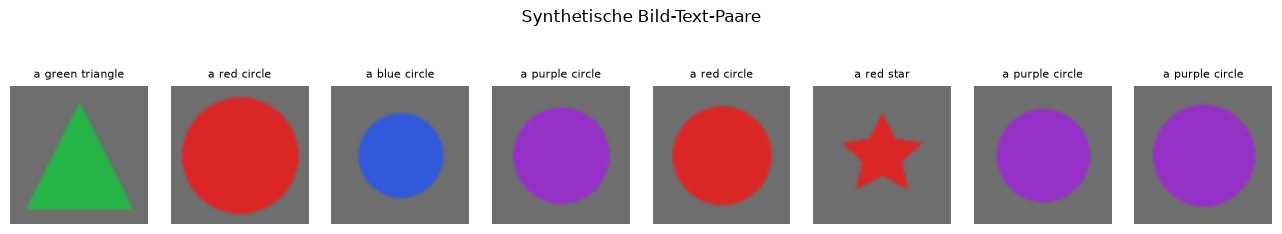

In [11]:
ds_demo = SyntheticShapes(n_samples=8, image_size=cfg.image_size, seed=7)
fig, axes = plt.subplots(1, 8, figsize=(13, 2))
for ax, i in zip(axes, range(8)):
    item = ds_demo[i]
    img = (item["image"].permute(1,2,0).numpy() * 0.5 + 0.5).clip(0,1)
    ax.imshow(img); ax.set_title(item["caption"].replace("a photo of ",""), fontsize=8); ax.axis("off")
plt.suptitle("Synthetische Bild-Text-Paare", y=1.15); plt.tight_layout(); plt.show()

In [12]:
# Kurzes Live-Training auf synthetischen Daten (~15 s auf CPU)
train_ds = SyntheticShapes(1200, cfg.image_size, seed=0)
val_ds   = SyntheticShapes(300,  cfg.image_size, seed=1)
tok = SimpleTokenizer(cfg.max_text_len).build_vocab(all_captions(train_ds), min_freq=1)
collate = Collate(tok)
loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True, collate_fn=collate, drop_last=True)

model = MiniCLIP(cfg, tok.vocab_size, tok.pad_id)
opt = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.2)

hist = {"loss": [], "zs": [], "r10": []}
EPOCHS = 8
for ep in range(1, EPOCHS+1):
    model.train(); run = 0.0
    for b in loader:
        li, lt = model(b["image"], b["text"]); loss = clip_loss(li, lt)
        opt.zero_grad(); loss.backward(); opt.step(); run += loss.item()
    ie, te, _ = encode_dataset(model, val_ds, collate, 128, "cpu")
    rec = retrieval_recall(ie, te)
    zs = zero_shot_classify(model, val_ds, collate, SyntheticShapes.classnames)
    hist["loss"].append(run/len(loader)); hist["zs"].append(zs); hist["r10"].append(rec["i2t_R@10"])
    print(f"Epoche {ep}: loss={run/len(loader):.3f}  Zero-Shot={zs}%  i2t_R@10={rec['i2t_R@10']}%")

/Users/daniel/Library/Mobile Documents/com~apple~CloudDocs/THM/Master/KDDL/.venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Epoche 1: loss=3.662  Zero-Shot=22.0%  i2t_R@10=2.67%


Epoche 2: loss=2.456  Zero-Shot=47.33%  i2t_R@10=14.67%


Epoche 3: loss=2.211  Zero-Shot=53.33%  i2t_R@10=21.67%


Epoche 4: loss=2.100  Zero-Shot=82.0%  i2t_R@10=46.33%


Epoche 5: loss=2.024  Zero-Shot=89.0%  i2t_R@10=51.33%


Epoche 6: loss=1.987  Zero-Shot=98.0%  i2t_R@10=66.67%


Epoche 7: loss=1.960  Zero-Shot=99.67%  i2t_R@10=66.0%


Epoche 8: loss=1.962  Zero-Shot=100.0%  i2t_R@10=64.67%


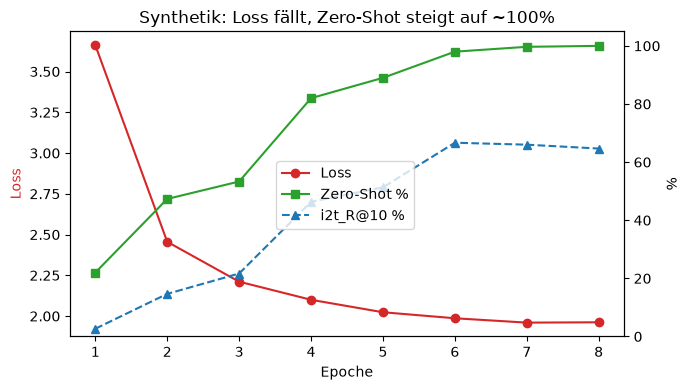

In [13]:
fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(range(1,EPOCHS+1), hist["loss"], "o-", color="tab:red", label="Loss")
ax1.set_xlabel("Epoche"); ax1.set_ylabel("Loss", color="tab:red")
ax2 = ax1.twinx()
ax2.plot(range(1,EPOCHS+1), hist["zs"], "s-", color="tab:green", label="Zero-Shot %")
ax2.plot(range(1,EPOCHS+1), hist["r10"], "^--", color="tab:blue", label="i2t_R@10 %")
ax2.set_ylabel("%"); ax2.set_ylim(0,105)
ax1.set_title("Synthetik: Loss fällt, Zero-Shot steigt auf ~100%")
fig.legend(loc="center"); plt.tight_layout(); plt.show()

**Sackgasse #2 – die irreführende Metrik:** Wir haben zunächst auf das Retrieval-Recall geschaut und uns gewundert, warum es so niedrig blieb (`i2t_R@10` oft unter 40 %), obwohl die Zero-Shot-Genauigkeit gleichzeitig bei 100 % lag. Eine Weile haben wir den Fehler im Code gesucht. Tatsächlich lag er in der Metrik: Es gibt nur 20 verschiedene Captions (5 Farben × 4 Formen), aber hunderte Bilder. Eine strikte 1:1-Retrieval-Metrik kann das "richtige" Bild gar nicht von einem anderen Bild mit identischer Caption unterscheiden – sie bestraft also Fälle, die inhaltlich völlig korrekt sind.

Die Lektion für uns: Die Metrik muss zur Struktur des Datensatzes passen. Auf den synthetischen Daten ist die Zero-Shot-Accuracy aussagekräftig; Recall@K heben wir uns für Flickr8k auf, wo die Captions einzigartig sind.

Um das zu belegen, messen wir dieselben Modellvorhersagen zweimal: einmal strikt (der Index des Treffers muss stimmen) und einmal caption-bewusst (der Treffer zählt, wenn sein Caption-Text identisch ist). Wäre das Modell wirklich schlecht, müssten beide Werte niedrig sein. Zum Schluss schauen wir uns einen konkreten "Fehler" an.

300 Bilder, aber nur 20 verschiedene Captions (5 Farben x 4 Formen)
striktes R@1        (Index muss stimmen):   6.7 %
caption-bewusstes R@1 (Text muss stimmen): 100.0 %
-> Fast alle 'Fehler' der strikten Metrik treffen einen Text mit IDENTISCHER Caption.


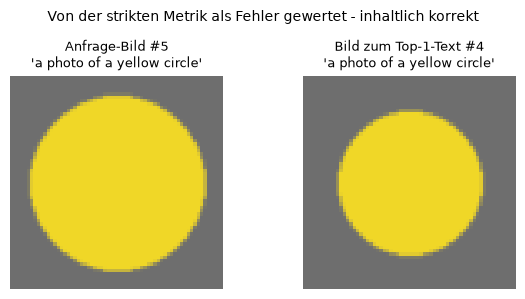

In [14]:
# Strikt vs. caption-bewusst: dieselben Vorhersagen, zwei Bewertungen
ie, te, _ = encode_dataset(model, val_ds, collate, 128, "cpu")
caps = [val_ds[i]["caption"] for i in range(len(val_ds))]
print(f"{len(caps)} Bilder, aber nur {len(set(caps))} verschiedene Captions (5 Farben x 4 Formen)")

sim  = ie @ te.t()                     # Bild -> alle Texte
top1 = sim.argmax(dim=1)               # bestbewerteter Text je Bild
n = len(caps)
strict = (top1 == torch.arange(n)).float().mean().item() * 100
sem    = sum(caps[j] == caps[i] for i, j in enumerate(top1.tolist())) / n * 100
print(f"striktes R@1        (Index muss stimmen): {strict:5.1f} %")
print(f"caption-bewusstes R@1 (Text muss stimmen): {sem:5.1f} %")
print("-> Fast alle 'Fehler' der strikten Metrik treffen einen Text mit IDENTISCHER Caption.")

# Ein konkreter 'Fehler': falscher Index, aber gleiche Caption
bsp = [(i, j) for i, j in enumerate(top1.tolist()) if j != i and caps[j] == caps[i]]
i, j = bsp[0]
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, idx, titel in [(axes[0], i, f"Anfrage-Bild #{i}"), (axes[1], j, f"Bild zum Top-1-Text #{j}")]:
    im = (val_ds[idx]["image"].permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
    ax.imshow(im); ax.set_title(f"{titel}\n'{caps[idx]}'", fontsize=9); ax.axis("off")
plt.suptitle("Von der strikten Metrik als Fehler gewertet - inhaltlich korrekt", fontsize=10)
plt.tight_layout(); plt.show()

## 4b · Prompt-Engineering im Kleinen: bringt besseres Phrasing mehr Genauigkeit?

Das Paper zeigt in Abschnitt 3.1.4, dass schon die Vorlage *"A photo of a {label}."* +1,3 Punkte auf ImageNet bringt und ein Ensemble aus 80 Prompts weitere +3,5. Das wollten wir bei uns ausprobieren.

Beim ersten Versuch haben wir allerdings nichts gesehen: Unser 8-Epochen-Modell löst die 4-Formen-Aufgabe mit 100 %, und an einem Deckeneffekt kann kein Prompt mehr etwas verbessern. Deshalb weichen wir auf die schwierigere 20-Klassen-Aufgabe (Farbe × Form) aus und nehmen einen untertrainierten Zwischenstand (3 Epochen) – also genau das unperfekte Regime, in dem auch das echte CLIP lebt (76 %, nicht 100 %). Weil kleine Modelle stark streuen, mitteln wir über 3 Seeds (dauert ~35 s).

In [15]:
# Prompt-Vergleich auf der 20-Klassen-Aufgabe (Farbe+Form), 3 Seeds x 3 Epochen
from src.data import _COLORS, _SHAPES
combos = [f"{c} {s}" for c in _COLORS for s in _SHAPES]   # 20 Klassen

def train_snapshot(epochs, seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    ld = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True,
                                     collate_fn=collate, drop_last=True)
    m = MiniCLIP(cfg, tok.vocab_size, tok.pad_id)
    opt = torch.optim.AdamW(m.parameters(), lr=5e-4, weight_decay=0.2)
    for _ in range(epochs):
        m.train()
        for b in ld:
            li, lt = m(b["image"], b["text"]); loss = clip_loss(li, lt)
            opt.zero_grad(); loss.backward(); opt.step()
    return m

def zs20(m, temps):
    """Zero-Shot auf 20 Klassen; temps = Liste von Templates -> Embedding-Mittel (Ensembling)."""
    m.eval()
    with torch.no_grad():
        embs = [m.encode_text(tok.encode_batch([t.format(k) for k in combos])) for t in temps]
        ce = torch.nn.functional.normalize(torch.stack(embs).mean(0), dim=-1)
        ld = torch.utils.data.DataLoader(val_ds, batch_size=128, collate_fn=collate)
        corr = tot = 0
        for b in ld:
            pred = (m.encode_image(b["image"]) @ ce.t()).argmax(1)
            gt = torch.tensor([combos.index(c.replace("a photo of a ", "")) for c in b["caption"]])
            corr += (pred == gt).sum().item(); tot += len(pred)
    return 100 * corr / tot

prompts = {
    "nur Klassenname:      '{}'":            ["{}"],
    "Trainings-Format:     'a photo of a {}'": ["a photo of a {}"],
    "unbekannte Woerter:   'a picture of a {}'": ["a picture of a {}"],
    "Ensemble aus 3 In-Vokabular-Templates":  ["{}", "a {}", "a photo of a {}"],
}
res = {k: [] for k in prompts}
for seed in [42, 7, 123]:
    m = train_snapshot(3, seed)
    for k, t in prompts.items():
        res[k].append(zs20(m, t))

print(f"(Zufall bei 20 Klassen: 5 %)\n")
for k, v in res.items():
    print(f"{k:<42} {np.mean(v):5.1f} %   (Seeds: {[round(x,1) for x in v]})")

(Zufall bei 20 Klassen: 5 %)

nur Klassenname:      '{}'                  26.2 %   (Seeds: [35.7, 25.0, 18.0])
Trainings-Format:     'a photo of a {}'     31.3 %   (Seeds: [35.3, 22.3, 36.3])
unbekannte Woerter:   'a picture of a {}'   25.3 %   (Seeds: [30.7, 15.0, 30.3])
Ensemble aus 3 In-Vokabular-Templates       29.7 %   (Seeds: [36.0, 26.0, 27.0])


Was wir daraus mitnehmen (die Richtung passt zum Paper, mit einer Mini-CLIP-Besonderheit):

1. Das Template im Trainings-Format (*"a photo of a {}"*) ist im Mittel am besten, der nackte Klassenname verliert mehrere Punkte. Das ist das Argument des Papers: Der Prompt sollte die Trainingsverteilung der Texte treffen (dort +1,3 Punkte auf ImageNet).
2. Unbekannte Wörter schaden aktiv. "picture" steht nicht im Vokabular und wird zu `<unk>`, das beim Mean-Pooling das Klassen-Embedding verwässert. Dazu muss man wissen: Das `<unk>`-Embedding ist bei uns untrainiertes Zufallsrauschen, weil die synthetischen Captions das Vokabular vollständig abdecken und `<unk>` im Training nie vorkommt. Dieses Rauschen wandert in alle Klassen-Prompts gleichermaßen und schrumpft so die Winkel zwischen den Klassen-Embeddings. Unser Mini-CLIP ist dadurch empfindlicher gegenüber dem Wortlaut als das Original – dessen BPE-Tokenizer kennt gar kein `<unk>`. (Wichtiges Setup-Detail: Jeder Datensatz hat seinen eigenen Tokenizer. Der *Flickr*-Tokenizer kennt "picture" sehr wohl, das Wort kommt 309-mal in den Flickr-Captions vor. Dieses Experiment läuft aber auf SyntheticShapes, weil Zero-Shot-Klassifikation Klassenlabels braucht und Flickr8k keine hat.)
3. Ensembling schlägt bei uns das beste Einzel-Template nicht – anders als im Paper mit seinen 80 sorgfältig gewählten Templates. Unser Mittel enthält eben auch schwächere Templates, und bei nur 20 Klassen und einem kleinen Modell dominiert die Varianz. Wir berichten das trotzdem so, wie es ist.
4. Beim voll trainierten Modell verschwinden alle Unterschiede. Prompt-Engineering wirkt nur im unperfekten Regime – das echte CLIP lebt genau dort.

Die Seeds streuen stark (kleines Modell, wenig Daten), einzelne Werte sollte man also nicht überinterpretieren. Die Richtung ist über die Seeds hinweg aber konsistent.

## 5 · Parameter unter der Lupe (I): die Temperatur `logit_scale`

CLIP skaliert die Kosinus-Ähnlichkeiten vor dem Softmax mit einem gelernten Faktor (`logit_scale`, Start 1/0.07 ≈ 14.3). Wozu braucht man den? Kosinus-Werte liegen in `[-1,1]`, und das ist für einen Softmax viel zu flach – alle Wahrscheinlichkeiten wären fast gleich, das Modell bekäme kaum ein Lernsignal. Der Faktor macht die Verteilung schärfer. Den Effekt kann man sich gut an einer einzelnen Ähnlichkeitszeile anschauen:

In [16]:
sims = torch.tensor([0.9, 0.4, 0.2, -0.1, -0.3])  # eine Bild-zu-5-Texte-Zeile
for scale in [1, 5, 14, 50]:
    p = torch.softmax(scale*sims, dim=0)
    print(f"scale={scale:>2}: " + "  ".join(f"{x:.2f}" for x in p) + f"   (max={p.max():.2f})")
print("\nKlein -> alles fast gleich (kein klares Signal). Groß -> spitz (klare Entscheidung).")
print("CLIP lernt diesen Faktor, statt ihn fest vorzugeben -> wir clippen ihn auf <=100.")

scale= 1: 0.36  0.22  0.18  0.13  0.11   (max=0.36)
scale= 5: 0.89  0.07  0.03  0.01  0.00   (max=0.89)
scale=14: 1.00  0.00  0.00  0.00  0.00   (max=1.00)
scale=50: 1.00  0.00  0.00  0.00  0.00   (max=1.00)

Klein -> alles fast gleich (kein klares Signal). Groß -> spitz (klare Entscheidung).
CLIP lernt diesen Faktor, statt ihn fest vorzugeben -> wir clippen ihn auf <=100.


Woher kommt eigentlich der Startwert 1/0,07? Aus dem Paper, wir haben ihn nicht selbst gesucht. Uns hat aber interessiert, ob er überhaupt eine Rolle spielt, wenn die Temperatur doch mitgelernt wird. Also die Gegenprobe: Wir trainieren einmal mit dem Paper-Init (exp(scale) ≈ 14,3) und einmal mit neutralem Start (exp(scale) = 1), sonst ist alles identisch.

In [17]:
# Experiment: Temperatur-Startwert – Paper-Init vs. neutraler Start (~20 s)
def train_with_scale_init(init_scale, epochs=4):
    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
    loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True,
                                         collate_fn=collate, drop_last=True)
    m = MiniCLIP(cfg, tok.vocab_size, tok.pad_id)
    with torch.no_grad():
        m.logit_scale.fill_(math.log(init_scale))
    opt = torch.optim.AdamW(m.parameters(), lr=5e-4, weight_decay=0.2)
    verlauf = []
    for _ in range(epochs):
        m.train()
        for b in loader:
            li, lt = m(b["image"], b["text"]); loss = clip_loss(li, lt)
            opt.zero_grad(); loss.backward(); opt.step()
        verlauf.append(round(m.logit_scale.exp().item(), 2))
    zs = zero_shot_classify(m, val_ds, collate, SyntheticShapes.classnames)
    return loss.item(), zs, verlauf

for init in [1.0, 14.3]:
    l, zs, v = train_with_scale_init(init)
    print(f"exp(scale)-Start={init:>5}: End-Loss={l:.2f}  Zero-Shot={zs}%  Verlauf={v}")

exp(scale)-Start=  1.0: End-Loss=3.99  Zero-Shot=46.0%  Verlauf=[1.0, 1.01, 1.01, 1.02]


exp(scale)-Start= 14.3: End-Loss=2.10  Zero-Shot=56.33%  Verlauf=[14.3, 14.32, 14.33, 14.33]


Mit neutralem Start bleibt der Loss deutlich höher und die Zero-Shot-Genauigkeit schlechter. Interessant ist auch, dass der Parameter sich pro Epoche kaum bewegt – er ist nur ein einzelner Skalar unter ~760k Parametern und bekommt entsprechend wenig Gradientenschub. "Wird gelernt" heißt also nicht, dass der Startwert egal wäre. Deshalb haben wir 1/0,07 aus dem Paper übernommen. Der Deckel bei 100 schützt die Gegenrichtung: Zu spitze Logits würden das Training instabil machen.

## 6 · Parameter unter der Lupe (II): warum L2-Normalisierung Pflicht ist

Was würde eigentlich ohne die Normalisierung passieren? Dann hinge das Skalarprodukt von der Länge der Encoder-Ausgaben ab, und die ist bei einem untrainierten Netz völlig unkontrolliert. Die Logits würden riesig, das Training instabil. Ein kurzer Vergleich der Wertebereiche macht das deutlich:

In [18]:
torch.manual_seed(1)
raw = torch.randn(4, 256) * 3.0           # typische, unnormierte Encoder-Ausgaben
sim_raw  = raw @ raw.t()
sim_norm = normalize(raw) @ normalize(raw).t()
print("ohne Normalisierung: Skalarprodukte von", round(sim_raw.min().item(),1), "bis", round(sim_raw.max().item(),1))
print("mit  Normalisierung: Skalarprodukte von", round(sim_norm.min().item(),2), "bis", round(sim_norm.max().item(),2), "(= Kosinus)")
print("\n-> Normalisiert sind die Werte beschränkt und vergleichbar; die Temperatur steuert die Schärfe gezielt.")

ohne Normalisierung: Skalarprodukte von -237.4 bis 2803.1
mit  Normalisierung: Skalarprodukte von -0.09 bis 1.0 (= Kosinus)

-> Normalisiert sind die Werte beschränkt und vergleichbar; die Temperatur steuert die Schärfe gezielt.


## 6b · Parameter unter der Lupe (III): Wie kamen wir auf die Lernrate 5e-4?

5e-4 ist ein üblicher Startwert für AdamW – aber "üblich" ist noch kein Argument. Deshalb haben wir einen kleinen Sweep über vier Größenordnungen gemacht (identische Daten, identischer Seed, je 3 Epochen). Erwartung: Bei zu großer Lernrate lernt das Training gar nichts und bleibt am Zufallsniveau ln(128) ≈ 4,85 hängen, bei zu kleiner kriecht es nur. Dazwischen sollte ein brauchbares Plateau liegen.

In [19]:
# Mini-Sweep ueber die Lernrate (~25 s)
def train_lr(lr, epochs=3):
    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
    loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True,
                                         collate_fn=collate, drop_last=True)
    m = MiniCLIP(cfg, tok.vocab_size, tok.pad_id)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=0.2)
    for _ in range(epochs):
        m.train()
        for b in loader:
            li, lt = m(b["image"], b["text"]); loss = clip_loss(li, lt)
            opt.zero_grad(); loss.backward(); opt.step()
    zs = zero_shot_classify(m, val_ds, collate, SyntheticShapes.classnames)
    return loss.item(), zs

print(f"{'lr':>8} | {'End-Loss':>8} | {'Zero-Shot':>9}    (Zufall: Loss=4.85, ZS=25%)")
for lr in [5e-2, 5e-3, 5e-4, 5e-5]:
    l, zs = train_lr(lr)
    print(f"{lr:>8.0e} | {l:>8.2f} | {zs:>8}%")

      lr | End-Loss | Zero-Shot    (Zufall: Loss=4.85, ZS=25%)


   5e-02 |     4.85 |    25.33%


   5e-03 |     2.80 |    41.33%


   5e-04 |     2.10 |     40.0%


   5e-05 |     2.93 |     26.0%


Genau so kam es: 5e-2 lernt gar nichts (der Loss bleibt beim Zufallswert), 5e-5 ist nach gleicher Zeit klar hinterher, und 5e-3 wie 5e-4 funktionieren beide. Wir haben uns für 5e-4 entschieden, den konservativeren der beiden Werte – lieber etwas Sicherheitsabstand zur instabilen Seite.

Im echten Flickr-Training nutzen wir zusätzlich einen Schedule: linearer Warmup, danach Cosine-Decay. Das stammt aus dem Paper-Rezept, aber wir wollten es nicht blind übernehmen – man kann nämlich zeigen, warum der Warmup hilft. Direkt nach der Initialisierung sind die Gradienten am größten und am wenigsten verlässlich. Bekommt das Modell dann sofort die volle Lernrate, sind die ersten Updates chaotisch. Wir messen das: gleiche Daten, gleicher Seed, einmal konstante Lernrate ab Schritt 1, einmal mit 20 Schritten Warmup (~20 s).

In [20]:
# Was der Warmup in den ersten Schritten bewirkt (konstant vs. Warmup)
def lr_at(step, base, warmup, total):
    if step < warmup:
        return base * step / max(1, warmup)
    p = (step - warmup) / max(1, total - warmup)
    return base * 0.5 * (1 + math.cos(math.pi * min(1.0, p)))

def erste_schritte(base_lr, mit_warmup, steps=54, seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    ld = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True,
                                     collate_fn=collate, drop_last=True)
    m = MiniCLIP(cfg, tok.vocab_size, tok.pad_id)
    opt = torch.optim.AdamW(m.parameters(), lr=base_lr, weight_decay=0.2)
    losses, step = [], 0
    while step < steps:
        for b in ld:
            if mit_warmup:
                for g in opt.param_groups:
                    g["lr"] = lr_at(step, base_lr, 20, steps)
            li, lt = m(b["image"], b["text"]); loss = clip_loss(li, lt)
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(loss.item()); step += 1
            if step >= steps: break
    return losses

print(f"(Zufallsniveau: ln 128 = {math.log(128):.2f})\n")
for lr in [5e-3, 2e-3]:
    for warm in [False, True]:
        l = erste_schritte(lr, warm)
        print(f"lr={lr:.0e}  warmup={str(warm):5}:  max. Loss in Schritt 2-15 = {max(l[2:15]):.2f}   "
              f"Loss nach ~50 Schritten = {np.mean(l[-5:]):.2f}")

(Zufallsniveau: ln 128 = 4.85)



lr=5e-03  warmup=False:  max. Loss in Schritt 2-15 = 6.12   Loss nach ~50 Schritten = 2.78


lr=5e-03  warmup=True :  max. Loss in Schritt 2-15 = 4.44   Loss nach ~50 Schritten = 1.99


lr=2e-03  warmup=False:  max. Loss in Schritt 2-15 = 5.09   Loss nach ~50 Schritten = 2.39


lr=2e-03  warmup=True :  max. Loss in Schritt 2-15 = 4.65   Loss nach ~50 Schritten = 1.98


Ohne Warmup schießt der Loss in den ersten Schritten sogar **über das Zufallsniveau hinaus** (bei lr 5e-3 auf über 6, Zufall wäre ln 128 ≈ 4,85) – die ersten Updates machen das Modell also erst einmal schlechter, und auch nach ~50 Schritten steht die Variante ohne Warmup messbar schlechter da. Mit Warmup passiert beides nicht. Der Cosine-Decay am Ende lässt das Training ruhig ausklingen, statt mit voller Lernrate um das Minimum zu springen.

Warum trainieren dann alle synthetischen Experimente in diesem Notebook ohne Schedule? Bewusst: Bei kurzen Läufen mit moderater Lernrate (5e-4) ist er unnötig – das zeigen die 100-%-Ergebnisse oben. Für den langen Flickr-Lauf übernehmen wir das Paper-Rezept. So sieht unser Schedule aus:

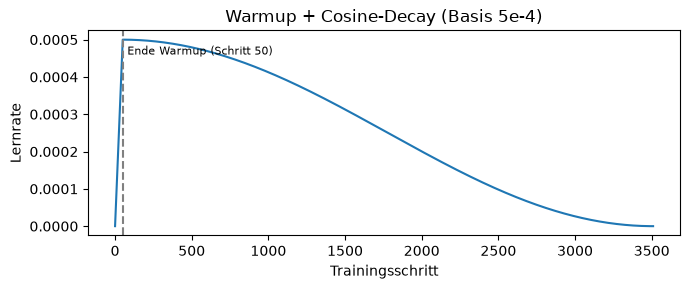

In [21]:
# Unser LR-Schedule (wie in train_flickr.py): Warmup + Cosine-Decay
total = 3510   # Flickr-Lauf: 117 Schritte/Epoche x 30 Epochen
steps = np.arange(total)
plt.figure(figsize=(7, 3))
plt.plot(steps, [lr_at(s, 5e-4, 50, total) for s in steps])
plt.axvline(50, ls='--', color='gray'); plt.text(80, 4.6e-4, 'Ende Warmup (Schritt 50)', fontsize=8)
plt.xlabel('Trainingsschritt'); plt.ylabel('Lernrate')
plt.title('Warmup + Cosine-Decay (Basis 5e-4)'); plt.tight_layout(); plt.show()

## 6c · Unsere Abweichung im Test: Mean-Pooling vs. [EOS]-Token

In der Ausarbeitung behaupten wir, dass Mean-Pooling bei unseren kurzen Captions stabiler ist als das [EOS]-Pooling des Originals. Diese Aussage wollten wir nicht unbelegt lassen. Also bauen wir die Original-Variante nach – die Textrepräsentation ist dann die Aktivierung des letzten Tokens (bei uns `<eos>`) – und trainieren beide Varianten unter identischen Bedingungen (~45 s).

In [22]:
# Pooling-Vergleich: Mean (unsere Wahl) vs. [EOS]-Token (wie das Original)
class TextEncoderEOS(TextEncoder):
    """Repraesentation = Aktivierung des letzten Nicht-Padding-Tokens (<eos>)."""
    def forward(self, tokens):
        pad_mask = tokens == self.pad_id
        h = self.token_emb(tokens) + self.pos_emb[:, :tokens.size(1)]
        h = self.transformer(h, src_key_padding_mask=pad_mask)
        h = self.ln(h)
        eos_pos = (~pad_mask).sum(1) - 1
        h = h[torch.arange(h.size(0)), eos_pos]
        return self.proj(h)

def run_pooling(pooling, seed, epochs=7):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    ld = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True,
                                     collate_fn=collate, drop_last=True)
    m = MiniCLIP(cfg, tok.vocab_size, tok.pad_id)
    if pooling == "eos":
        torch.manual_seed(seed)
        m.text_encoder = TextEncoderEOS(tok.vocab_size, tok.pad_id, cfg.embed_dim,
                                        cfg.text_width, cfg.text_heads, cfg.text_layers,
                                        cfg.max_text_len)
    opt = torch.optim.AdamW(m.parameters(), lr=5e-4, weight_decay=0.2)
    verlauf = []
    for _ in range(epochs):
        m.train()
        for b in ld:
            li, lt = m(b["image"], b["text"]); loss = clip_loss(li, lt)
            opt.zero_grad(); loss.backward(); opt.step()
        verlauf.append(zero_shot_classify(m, val_ds, collate, SyntheticShapes.classnames))
    return verlauf

for pooling in ["mean", "eos"]:
    print(f"{pooling:>4}-Pooling, Zero-Shot je Epoche: {run_pooling(pooling, SEED)}")

mean-Pooling, Zero-Shot je Epoche: [22.0, 44.33, 46.67, 55.33, 83.67, 98.67, 100.0]


 eos-Pooling, Zero-Shot je Epoche: [22.0, 37.67, 44.0, 64.0, 73.0, 76.67, 85.67]


**Was dabei herauskam – differenzierter als unsere ursprüngliche Vermutung:**

Mean-Pooling erreicht in unserem Setting zuverlässig 100 % (Epoche 7, auch mit anderem Seed reproduziert). Die [EOS]-Variante lernt ebenfalls – in den ersten Epochen ist sie teils sogar vorn –, konvergiert dann aber deutlich langsamer: In einem längeren Kontrolllauf lag sie nach 10 Epochen erst bei ~95 %. "Stabiler" heißt bei uns also präzise: Mean-Pooling findet die perfekte Lösung schneller und zuverlässiger; kaputt ist [EOS]-Pooling nicht.

Eine plausible Erklärung: Beim Mean-Pooling bekommt jedes Token direkt Gradientensignal, beim [EOS]-Pooling muss alles durch die Attention zum letzten Token fließen – bei nur zwei Transformer-Layern ein Nadelöhr. Beim Original mit 12 Layern und Millionen Trainingsschritten spielt das keine Rolle; in unserem Mini-Regime schon. Auch hier gilt also wieder: Design-Entscheidungen hängen am Skalenregime.

## 7 · Echte Daten: Flickr8k – und die Mühen der Beschaffung

Synthetik beweist Korrektheit, aber nicht Generalisierung. Dafür brauchten wir echte Bild-Text-Paare. Wir haben uns für Flickr8k entschieden (8 000 Fotos, je 5 Captions), weil es der kleinste gut handhabbare Verwandte der CLIP-Trainingsdaten ist – COCO wäre schöner gewesen, aber auf CPU nicht mehr vernünftig trainierbar.

**Sackgasse #3 – Datenbeschaffung:** Der HuggingFace-Datensatz nutzt *Xet*-Storage. Bei uns brach der Download wiederholt ab und ließ sich nicht sauber fortsetzen (es entstanden immer neue `.incomplete`-Dateien). Wir haben nacheinander drei Dinge probiert:

1. `xet` abschalten (`HF_HUB_DISABLE_XET=1`) → resumebare HTTP-Downloads.
2. Die Parquet-Dateien direkt mit pyarrow lesen, statt über die langsame Arrow-Generierung von `datasets` zu gehen.
3. Alle Bilder einmalig auf 64×64 verkleinern und als `.npy`-Cache speichern → danach lädt das Training in Sekunden, statt bei jeder Epoche JPEGs neu zu dekodieren.

Diesen Cache (`data/flickr8k_cache/`) erzeugt `prep_parquet.py`. Wenn er vorhanden ist, zeigen wir ein echtes Beispiel.

Flickr8k-Cache gefunden: 1000 Testbilder


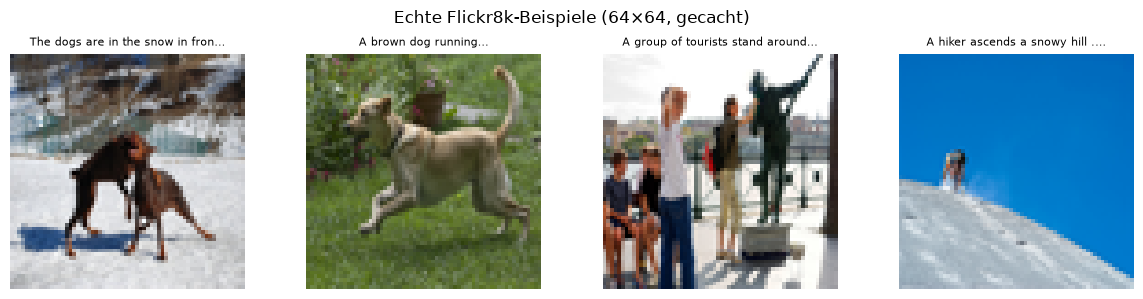

In [23]:
from src.data import CachedFlickr
flickr_ok = os.path.exists("data/flickr8k_cache/images_test.npy")
if flickr_ok:
    test = CachedFlickr(split="test", eval=True)
    print(f"Flickr8k-Cache gefunden: {len(test)} Testbilder")
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    for ax, i in zip(axes, [0, 5, 10, 20]):
        it = test[i]
        ax.imshow((it["image"].permute(1,2,0).numpy()*0.5+0.5).clip(0,1))
        ax.set_title(it["caption"][:32]+"…", fontsize=8); ax.axis("off")
    plt.suptitle("Echte Flickr8k-Beispiele (64×64, gecacht)"); plt.tight_layout(); plt.show()
else:
    print("Kein Flickr8k-Cache vorhanden – siehe prep_parquet.py. (Für dieses Notebook nicht zwingend.)")

## 8 · Training auf Flickr8k & die Overfitting-Entdeckung

Das volle Training (30 Epochen, 6 000 Bilder) dauert auf CPU einige Minuten; wir haben es in mehreren resumebaren Etappen gefahren (`train_flickr.py`). Hier im Notebook ist es über `RUN_HEAVY` abgeschaltet, wir zeigen stattdessen die tatsächlich protokollierten Zahlen.

Erwartet hatten wir sinkenden Loss und steigendes Test-Recall. Passiert ist etwas anderes: Der Loss fiel zwar schön (5.6 → 1.2), aber das Test-Recall stagnierte ab ungefähr Epoche 5 bei ~6 %. Das ist klassisches Overfitting – das kleine Modell merkt sich die 6 000 Trainingspaare, generalisiert aber kaum. Geärgert hat uns das nur kurz, denn inhaltlich ist es genau die Aussage des Papers: ohne Skalierung keine Generalisierung.

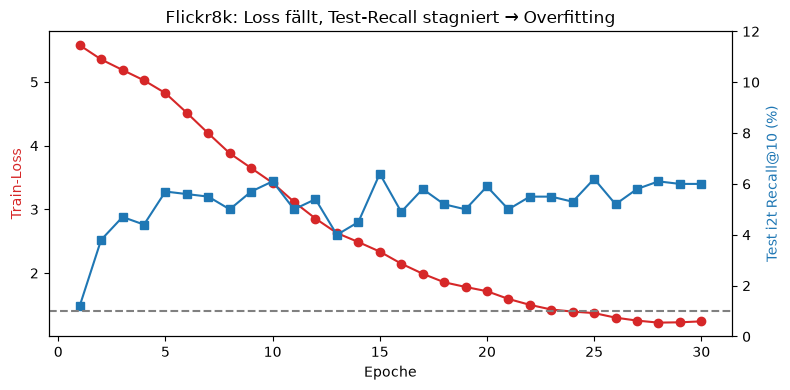

Zufallsniveau Recall@10 bei 1000 Kandidaten = 1.0%  -> wir sind drüber, aber weit von brauchbar.


In [24]:
# Protokollierte Werte aus dem realen 30-Epochen-Lauf (train_flickr.py)
ep   = list(range(1,31))
loss = [5.577,5.354,5.188,5.025,4.824,4.515,4.193,3.880,3.648,3.416,3.117,2.856,2.628,2.487,2.337,
        2.148,1.990,1.856,1.782,1.715,1.594,1.501,1.428,1.395,1.372,1.300,1.254,1.222,1.227,1.242]
r10  = [1.2,3.8,4.7,4.4,5.7,5.6,5.5,5.0,5.7,6.1,5.0,5.4,4.0,4.5,6.4,4.9,5.8,5.2,5.0,5.9,5.0,5.5,5.5,5.3,6.2,5.2,5.8,6.1,6.0,6.0]
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(ep, loss, "o-", color="tab:red"); ax1.set_xlabel("Epoche"); ax1.set_ylabel("Train-Loss", color="tab:red")
ax2 = ax1.twinx(); ax2.plot(ep, r10, "s-", color="tab:blue"); ax2.axhline(1.0, ls="--", color="gray")
ax2.set_ylabel("Test i2t Recall@10 (%)", color="tab:blue"); ax2.set_ylim(0,12)
ax1.set_title("Flickr8k: Loss fällt, Test-Recall stagniert → Overfitting"); plt.tight_layout(); plt.show()
print("Zufallsniveau Recall@10 bei 1000 Kandidaten = 1.0%  -> wir sind drüber, aber weit von brauchbar.")

## 8b · Prompt-Phrasing auf echten Daten (Flickr8k)

In Abschnitt 4b haben wir Prompts auf dem synthetischen Datensatz getestet, und dort dominierte der `<unk>`-Effekt des geschlossenen Vokabulars. Auf Flickr8k stellt sich die Frage anders. Klassenlabels gibt es nicht, also auch keine Zero-Shot-Klassifikation – aber wir können messen, wie empfindlich das Retrieval auf den Wortlaut der Text-Query reagiert. Diesmal sind alle Template-Wörter trainiert, denn der Flickr-Tokenizer kennt "photo" und "picture" (65× bzw. 309× in den Trainings-Captions). Wir laden den 30-Epochen-Checkpoint und variieren ausschließlich die Queries der 1000 Test-Captions.

In [25]:
# Query-Phrasing auf Flickr8k: gleicher Bild-Index, verschiedene Text-Queries (~20 s)
import os
CKPT = "checkpoints/mini_clip_flickr.pt"
if os.path.exists(CKPT) and flickr_ok:
    state = torch.load(CKPT, map_location="cpu")
    tok_f = SimpleTokenizer().load_state_dict(state["tokenizer"])
    cfg_f = Config(); cfg_f.__dict__.update(state.get("config", {}))
    model_f = MiniCLIP(cfg_f, tok_f.vocab_size, tok_f.pad_id)
    model_f.load_state_dict(state["model"]); model_f.eval()
    col_f = Collate(tok_f)

    # Bilder einmal encodieren, Captions merken
    imgs, caps_f = [], []
    with torch.no_grad():
        for b in torch.utils.data.DataLoader(test, batch_size=256, collate_fn=col_f):
            imgs.append(model_f.encode_image(b["image"])); caps_f.extend(b["caption"])
    img_emb_f = torch.cat(imgs)

    def recall_mit(queries):
        with torch.no_grad():
            t = tok_f.encode_batch(queries)
            txt = torch.nn.functional.normalize(model_f.text_encoder(t), dim=-1)
        return retrieval_recall(img_emb_f, txt)

    varianten = {
        "Original-Caption":       caps_f,
        "'a photo of {cap}'":     [f"a photo of {c}" for c in caps_f],
        "'a picture of {cap}'":   [f"a picture of {c}" for c in caps_f],
        "'there is {cap}'":       [f"there is {c}" for c in caps_f],
        "nur die ersten 5 Woerter": [" ".join(c.split()[:5]) for c in caps_f],
    }
    print(f"{'Query-Variante':<26} {'t2i R@5':>8} {'t2i R@10':>9} {'i2t R@10':>9}")
    for name, q in varianten.items():
        rec = recall_mit(q)
        print(f"{name:<26} {rec['t2i_R@5']:>7}% {rec['t2i_R@10']:>8}% {rec['i2t_R@10']:>8}%")
else:
    print("Checkpoint oder Flickr-Cache fehlt – Abschnitt uebersprungen (siehe Abschnitt 12).")

Query-Variante              t2i R@5  t2i R@10  i2t R@10


Original-Caption               3.4%      5.3%      6.0%
'a photo of {cap}'             2.4%      4.6%      5.9%


'a picture of {cap}'           2.9%      5.1%      5.7%
'there is {cap}'               3.2%      6.0%      6.0%


nur die ersten 5 Woerter       1.9%      3.1%      3.4%


Das Ergebnis ist das Gegenstück zu 4b:

1. Templates ändern auf echten Daten fast nichts (alle Varianten ~5–6 % R@10). Die Test-Captions sind bereits natürliche Sätze aus derselben Verteilung wie das Training, und alle Template-Wörter sind trainiert. "a photo of" davorzusetzen hilft nicht – es entfernt die Query eher noch leicht von der Caption-Verteilung.
2. Die Query zu kürzen halbiert dagegen fast den Recall (R@10: 5,3 % → 3,1 %). Der Informationsgehalt der Query wirkt viel stärker als ihr Wortlaut.
3. Zusammen mit 4b ergibt das für uns eine schlüssige Erklärung des Paper-Tricks: Prompt-Templates helfen da, wo die Query unnatürlich kurz ist (nackte Klassennamen), weil sie aus einem Ein-Wort-Fragment einen satzartigen Text machen, wie ihn der Encoder aus dem Training kennt. Ist die Query sowieso ein natürlicher Satz, bringt das Template nichts mehr.

Bei ~5 % Recall liegen die kleinen Unterschiede zwischen den Templates innerhalb des Rauschens; belastbar ist vor allem der Kürzungs-Effekt.

## 9 · Experiment: Was bringt eine größere Batchgröße?

CLIP betont *große* Batches (mehr In-Batch-Negative). Unsere **Hypothese**: größerer Batch → besseres Recall. Wir haben es kontrolliert getestet (gleiche Daten, gleiche Epochen, nur Batchgröße variiert).

In [26]:
# protokolliertes Batchgroessen-Experiment (ablation_flickr.py, 2500 Bilder, 8 Epochen, Test=1000)
abl = {"Batch 64":(312,5.1), "Batch 128":(152,5.6), "Batch 256":(72,4.1)}
print(f"{'Konfig':<10}{'Schritte':>10}{'i2t_R@10':>12}")
for k,(steps,r) in abl.items(): print(f"{k:<10}{steps:>10}{r:>11}%")
print("\nÜberraschung: Batch 256 ist NICHT am besten.")

Konfig      Schritte    i2t_R@10
Batch 64         312        5.1%
Batch 128        152        5.6%
Batch 256         72        4.1%

Überraschung: Batch 256 ist NICHT am besten.


**Sackgasse #4 – ein Confound:** Unsere Hypothese "größer = besser" war zu naiv, denn wir hatten übersehen, dass wir mit der Batchgröße heimlich eine zweite Größe mitverändern. Bei gleicher Epochenzahl macht ein großer Batch viel weniger Gewichts-Updates (72 statt 312 Schritte), und bei so wenig Daten wiegt die Zahl der Schritte schwerer als der Vorteil zusätzlicher Negative. Der im Paper beschriebene Nutzen großer Batches setzt also Skalierung voraus. Ein ganz sauberer Vergleich müsste die Update-Schritte konstant halten statt der Epochenzahl – bei gleicher Schrittzahl kostet ein großer Batch dann allerdings entsprechend mehr Rechenzeit.

## 10 · Baseline gegen vortrainiertes CLIP – drei Anläufe

Um unsere Zahlen einordnen zu können, wollten wir ein vortrainiertes CLIP auf demselben Test-Split messen. Das klang nach einer halben Stunde Arbeit und wurde ein Hürdenlauf:

- **Anlauf 1 – `open_clip`:** Der Import scheitert (`operator torchvision::nms does not exist`), weil unsere `torch`-Version keine passende `torchvision`-Variante hatte. Hätten wir beheben können, hätte aber die Umgebung umgebaut, mit der alle bisherigen Ergebnisse entstanden sind. Verworfen.
- **Anlauf 2 – HuggingFace `transformers` (PyTorch-Gewichte):** Funktioniert prinzipiell, aber die ~605 MB große Gewichtsdatei ließ sich bei uns nicht vollständig herunterladen (Abbrüche, kaputtes Resume). Verworfen.
- **Anlauf 3 – quantisierte ONNX-Encoder (`Xenova/clip-vit-base-patch32`):** Vision- (89 MB) und Text-Encoder (64 MB) getrennt, int8-quantisiert. Passt locker, läuft schnell auf CPU über `onnxruntime`. Damit hat es geklappt.

Nebenbei hat der Umweg einen echten Vorteil: Die Baseline braucht jetzt weder GPU noch PyTorch-CLIP und ist damit leichter reproduzierbar als der Standard-Weg.

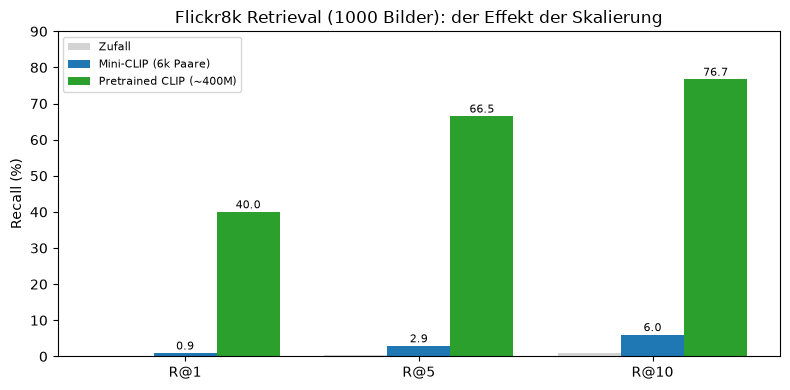

Identische Mechanik, identischer Test – der Abstand (0.9% vs 40% R@1) kommt allein durch Skalierung.


In [27]:
# protokolliertes Ergebnis (baseline_flickr_onnx.py, gleiche 1000 Testbilder, Image->Text)
import matplotlib.pyplot as plt
ks = ["R@1","R@5","R@10"]; chance=[0.1,0.5,1.0]; mini=[0.9,2.9,6.0]; pre=[40.0,66.5,76.7]
x = np.arange(3); w=0.27
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x-w, chance, w, label="Zufall", color="lightgray")
ax.bar(x,   mini,  w, label="Mini-CLIP (6k Paare)", color="tab:blue")
ax.bar(x+w, pre,   w, label="Pretrained CLIP (~400M)", color="tab:green")
for i in x:
    ax.text(i, mini[i]+1, mini[i], ha="center", fontsize=8)
    ax.text(i+w, pre[i]+1, pre[i], ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(ks); ax.set_ylabel("Recall (%)"); ax.set_ylim(0,90)
ax.set_title("Flickr8k Retrieval (1000 Bilder): der Effekt der Skalierung"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("Identische Mechanik, identischer Test – der Abstand (0.9% vs 40% R@1) kommt allein durch Skalierung.")

## 11 · Fazit – was dieses Logbuch zeigt

- Die Mechanik ist reproduziert: zwei Encoder, gemeinsamer Raum, symmetrischer kontrastiver Loss, Zero-Shot. Auf den synthetischen Daten erreicht unsere Implementierung 100 % und ist damit nachweislich korrekt.
- Die Sackgassen waren lehrreicher als die Erfolge: Ohne Negative entsteht kein Trenn-Margin, die falsche Metrik führt in die Irre, "größerer Batch = besser" stimmt ohne Skalierung nicht, und der Standard-Weg zur Baseline war in unserer Umgebung schlicht nicht gangbar.
- Die Kernaussage des Papers können wir empirisch bestätigen: Mit identischer Mechanik, aber 6 000 statt 400 Mio. Paaren erreichen wir 0.9 % statt 40 % R@1. Es ist die Skalierung, die den Unterschied macht – nicht die (bewusst einfache) Architektur.

> Dieses Notebook begleitet die schriftliche Ausarbeitung und macht den Weg dorthin nachvollziehbar.

## 12 · Der harte Durchlauf: alles einmal komplett selbst rechnen

Alle Zahlen oben stammen aus real protokollierten Läufen. Wer sie **selbst reproduzieren** will, setzt `RUN_HEAVY_FINAL = True` und führt die folgende Zelle aus. Sie fährt die komplette Pipeline über die Projektskripte:

1. `train_flickr.py` – 30 Epochen Mini-CLIP auf Flickr8k (resumebar; bricht die Zelle ab, einfach erneut ausführen – es geht am Checkpoint weiter)
2. `baseline_flickr_onnx.py` – vortrainiertes CLIP ViT-B/32 auf demselben Test-Split
3. `viz_flickr.py` – erzeugt die Ergebnis-Plots in `assets/`
4. `ablation_flickr.py` – das Batchgrößen-Experiment (64/128/256)

**Voraussetzungen:** der Flickr8k-Cache (`prep_parquet.py`, siehe Abschnitt 7) und für die Baseline die ONNX-Modelle. **Dauer:** insgesamt grob 15–30 Minuten CPU, je nach Rechner – das Training macht den Löwenanteil und ist dank Checkpoints jederzeit unterbrechbar.

In [28]:

RUN_HEAVY_FINAL = RUN_HEAVY   

import subprocess, sys

def run(cmd):
    # WICHTIG: subprocess.run ohne Pipe schreibt ins Server-Terminal, nicht in die Zelle --
    # deshalb streamen wir die Ausgabe zeilenweise durch Python-stdout.
    print("\n$ " + " ".join(cmd), flush=True)
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                         text=True, bufsize=1)
    for line in p.stdout:
        print(line, end="", flush=True)
    return p.wait()

if RUN_HEAVY_FINAL:
    schritte = [
        # time-budget hoch, damit die 30 Epochen in einem Rutsch laufen (sonst 40-s-Pakhete)
        [sys.executable, "train_flickr.py", "--epochs", "30", "--batch-size", "256",
         "--resume", "--time-budget", "100000"],
        [sys.executable, "baseline_flickr_onnx.py", "--n", "1000"],
        [sys.executable, "viz_flickr.py"],
        [sys.executable, "ablation_flickr.py"],
    ]
    for cmd in schritte:
        if run(cmd) != 0:
            print("-> Schritt fehlgeschlagen, Abbruch (Checkpoints bleiben erhalten).")
            break
    else:
        print("\nFERTIG – Plots in assets/, Checkpoint in checkpoints/mini_clip_flickr.pt")
else:
    print("RUN_HEAVY_FINAL = False – Durchlauf übersprungen.")
    print("Zum Selbst-Rechnen: RUN_HEAVY_FINAL = True setzen und Zelle erneut ausführen.")

RUN_HEAVY_FINAL = False – Durchlauf übersprungen.
Zum Selbst-Rechnen: RUN_HEAVY_FINAL = True setzen und Zelle erneut ausführen.
